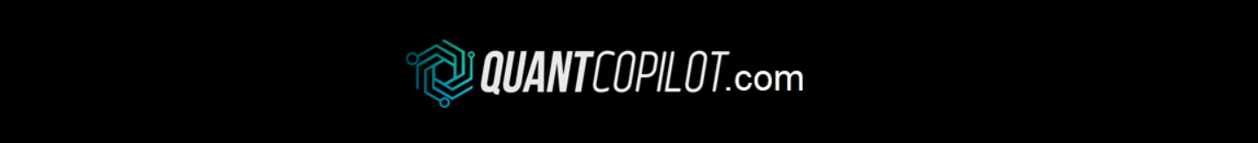

In [ ]:
# Mouning Drive
from google.colab import drive
drive.mount('/content/drive')

# Visualizando Datos con Matplotlib

In [ ]:
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.style
plt.style.use('ggplot')
# plt.style.use('seaborn')
# plt.style.use('fivethirtyeight')


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/[data_sets]/daily/TSLA-daily.csv") 

In [ ]:
data.head(3)

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-01-02,44.650002,42.652000,44.574001,43.862000,23822000.0,43.862000
1,2015-01-05,43.299999,41.431999,42.910000,42.018002,26842500.0,42.018002
2,2015-01-06,42.840000,40.841999,42.012001,42.256001,31309500.0,42.256001


In [ ]:
# Convirtiendo Date column (str) to DateTime
data['Date'] = pd.to_datetime(data['Date'])

# Estableciendo la columna 'Date' como el Index
data = data.set_index('Date')

In [ ]:
data.head(3)

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2015-01-02,44.650002,42.652000,44.574001,43.862000,23822000.0,43.862000
2015-01-05,43.299999,41.431999,42.910000,42.018002,26842500.0,42.018002
2015-01-06,42.840000,40.841999,42.012001,42.256001,31309500.0,42.256001


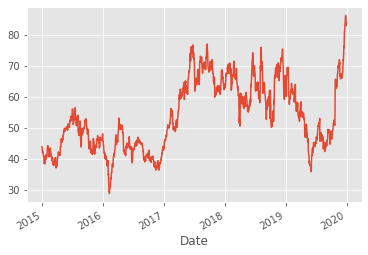

In [ ]:
data['Close'].plot()

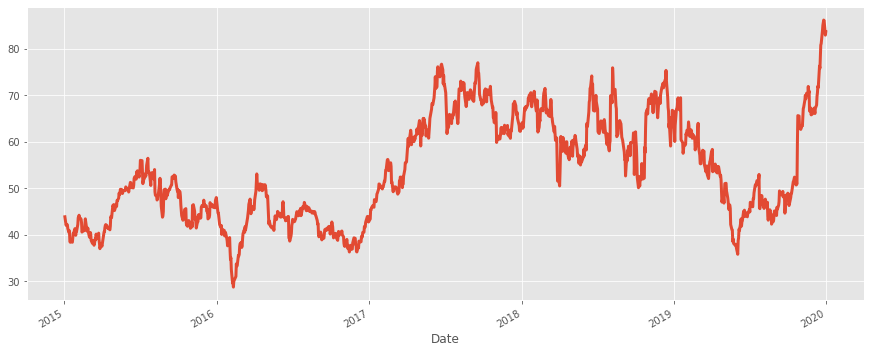

In [ ]:
data['Close'].plot(figsize=(15, 6), lw=3);

Ahora valos a plotear múltiples graficos (precio y volumen) dentro del mismo plot, usaremos ***. Subplot2grid *** que es una forma más fácil y conveniente de plotear múltiples gráficos, en lugar de usar * .subplot * que es más complejo de entender.

## Entendiendo **Subplot2grid**:

* Se crea el 1er grafico (top)
* shape=( *filas , columnas* ): Crea una CUADRICULA, la cual podemos controlar despues usando 'rowspan' y 'colspan' 
* loc=( *filas , columnas* ): Es la localizacion respecto a el Index de cada grafico en la cuadricula (shape). 

El orden en el que cuenta los cuadros y la localizacion en la cuadricula es de izquierda a derecha, y desde arriba hacia abajo, empezando desde el index **0**. Por ejemplo en una cuadricula 4x4 *(shape=(4,1))*, para plotear el grafico desde el inicio de la caudricula, 

Seria: Index de la Fila 0, e Index de la columna 0, y el grafico inferior, 

Seria: Index de la Fila 3, e Index de la columna 0, y el grafico inferior

Los atributos *rowspan* y *colspan*, especifican a cuantos cuadros en la cuadricula el grafico se va a expander

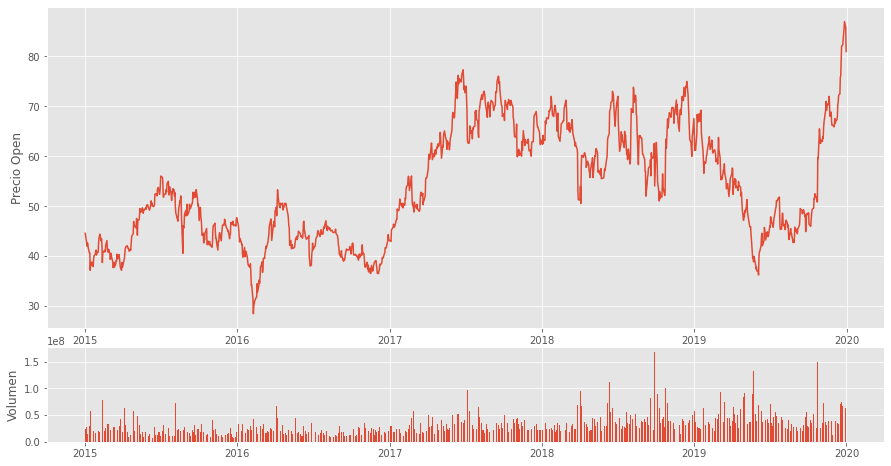

In [ ]:
graf_sup_izq = plt.subplot2grid(shape=(4,1), loc=(0, 0), rowspan=3, colspan=4)
graf_sup_izq.plot(data.index, data["Open"])
graf_sup_izq.set_ylabel('Precio Open')

graf_inferior = plt.subplot2grid(shape=(4,1), loc=(3,0), rowspan=1, colspan=4)
graf_inferior.bar(data.index, data['Volume'])
graf_inferior.set_ylabel('Volumen')

plt.gcf().set_size_inches(15,8)

## Visualizando OHLC con Matplotlib y Matplotlib Finance

Usaremos la libreria ***mplfinance*** (anteriormente: mpl-finance)

**IMPORTANTE:** Seguir esta guia tambien! https://github.com/matplotlib/mplfinance (muestra mas detalladamente como se va agregando Medias Moviles y Volumen, tambien muestra otros tipos de plots para time series finenceiro)

In [ ]:
pip install mplfinance

In [ ]:
import mplfinance as mpf

#### Visualizando OHLC en BARRAS

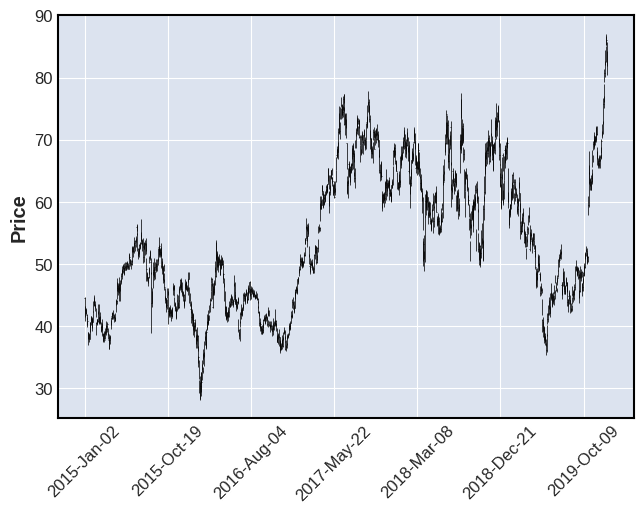

In [ ]:
# Visualizando todo el dataset
mpf.plot(data)

# Si no estás utilizando Jupyter, no olvides agregar la siguiente línea para visualizar este y los siguientes gráficos:
# plt.show()

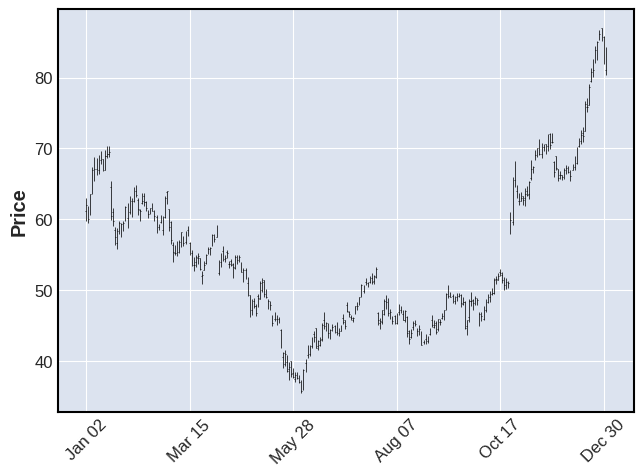

In [ ]:
# Visualizando solamente una parte del dataset
mpf.plot(data['2019':])

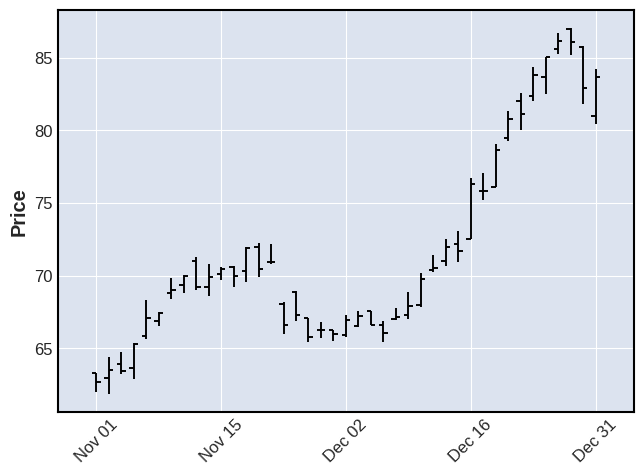

In [ ]:
# Visualizando solamente una parte del dataset
mpf.plot(data['2019-11':])

#### Visualizando OHLC en VELAS (Candlesticks)

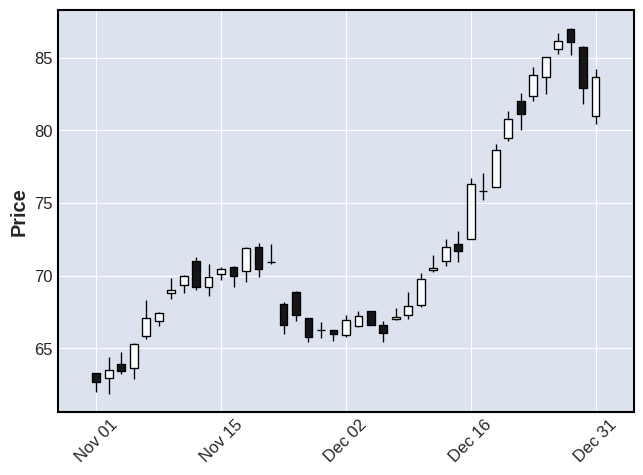

In [ ]:
mpf.plot(data['2019-11':], type='candle')

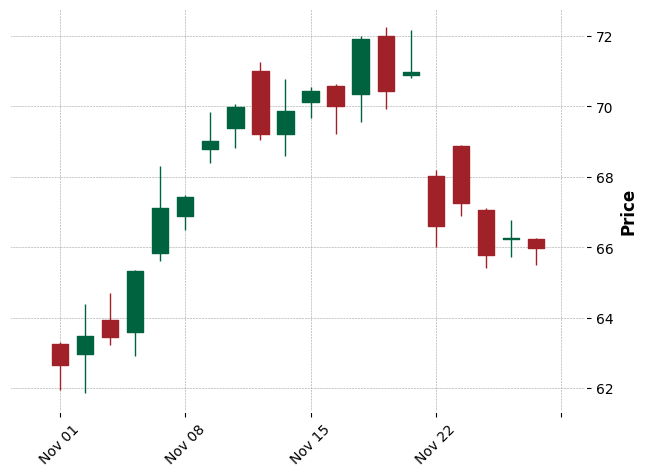

In [ ]:
mpf.plot(data["2019-11"], type='candle', style='charles')

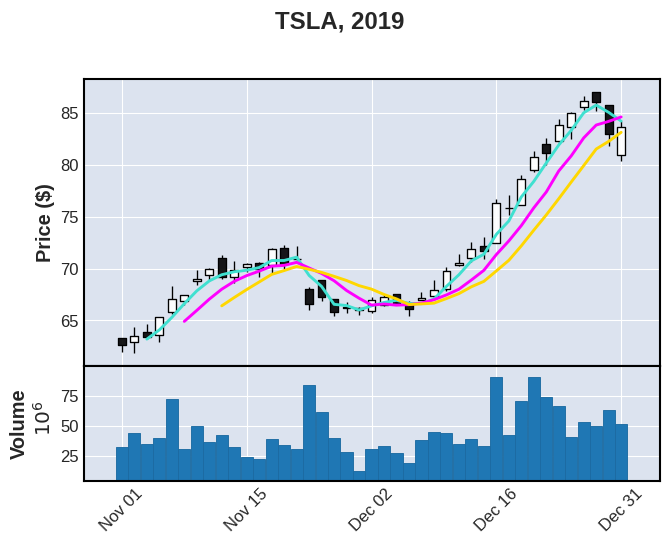

In [ ]:
mpf.plot(data["2019-11":], type='candle',
            title='TSLA, 2019',
            ylabel='Price ($)',
            ylabel_lower='Volume',
            volume=True, 
            mav=(3,6,9)
        #  savefig='test-mplfiance.png'
            )

### Estilos Varios en mplfinance

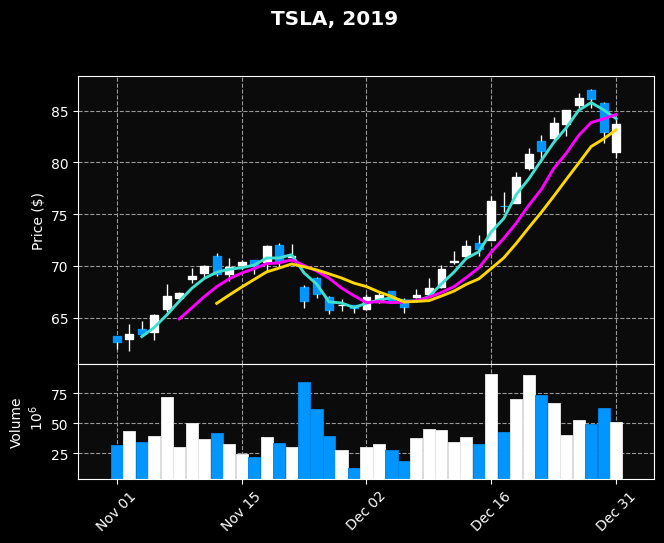

In [ ]:
mpf.plot(data["2019-11":], 
         type='candle',
          style='nightclouds', 
          # style='classic', 
          # style='charles', 
          # style='mike', 
          # style='yahoo', 
         title='TSLA, 2019',
         ylabel='Price ($)',
         ylabel_lower='Volume',
         volume=True, 

         mav=(3,6,9), # Medias Moviles

        
            )

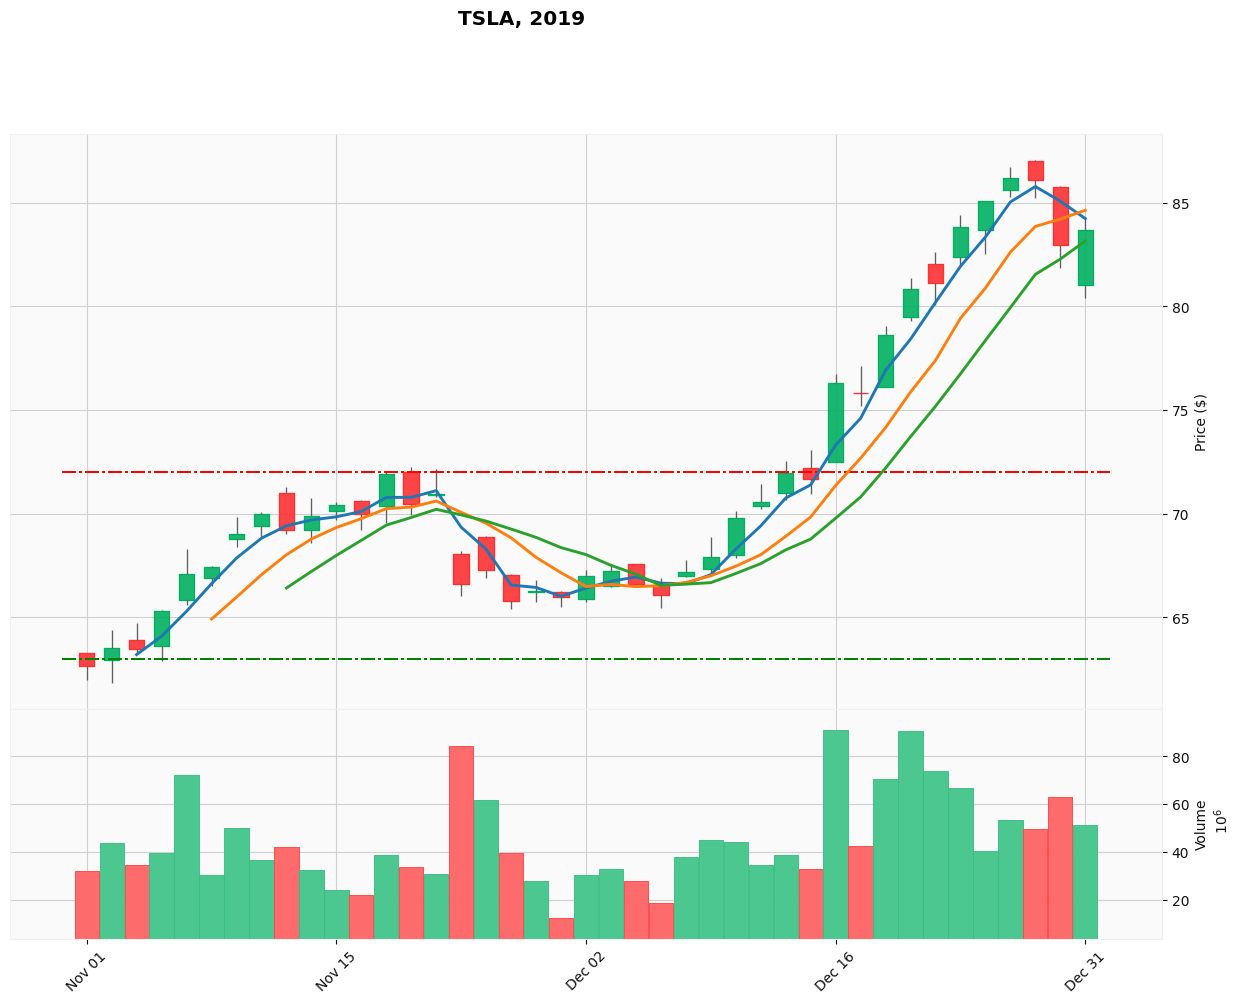

In [ ]:
mpf.plot(data["2019-11":], 
         type='candle',
         style='yahoo',
         title='TSLA, 2019',
         ylabel='Price ($)',
         ylabel_lower='Volume',
         volume=True, 

         mav=(3,6,9), # Moving Averages

        #  Lineas de soporte y resistencia
         hlines=dict(hlines=[63,72],colors=['g','r'],linestyle='-.'),

        # tamano del grafico  
         figscale=2.0         
            )

In [ ]:
mpf.plot(data["2019-11":], 
         type='candle',
         style='yahoo',
         title='TSLA, 2019',
         ylabel='Price ($)',
         ylabel_lower='Volume',
         volume=True, 

         mav=(3,6,9), # Moving Averages

        #  Lineas de soporte y resistencia
         hlines=dict(hlines=[63,72],colors=['g','r'],linestyle='-.'),

        # Marcar un area
         vlines=dict(vlines='2019-12-19',linewidths=100,alpha=0.4), 

         figscale=2.0,

         savefig='/content/drive/MyDrive/Colab Notebooks/grafico1.png'

        )

### Exportando / Guardando Graficos:
Simplemente se anade: 
- **savefig=** *'--- ruta y nombre del nuevo archivo .png ---'* a los parametros del plot <br>*(Seguir el codigo de arriba)*

https://es.quantcopilot.com/education/